## Step 1: Importing Libraries and Loading Dataset

#I start by importing the necessary libraries for data manipulation, visualization, text processing, and machine learning. The dataset is loaded into a Pandas DataFrame for easy analysis. This step ensures that all dependencies are available for the project

Import libraries like pandas, numpy, matplotlib, seaborn, and nltk for text processing.
Load the dataset using pd.read_csv.

In [33]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import re
import nltk




In [64]:
# Load dataset (assuming the dataset is in CSV format)
df = pd.read_csv("data_imdb.csv")
# Display the data structure
df.head()



,review,sentiment
0,"""A bored television director is introduced to ...",negative
1,"""American Nightmare"" is officially tied, in my...",negative
2,"""Fate"" leads Walter Sparrow to come in possess...",negative
3,"""I presume you are here for damage to your men...",negative
4,"""Mararía"" really disappointed me. I can't cons...",negative


## Step 2: Data Exploration
Analyze trends, missing values, and class imbalance.
In this step, we explore the dataset to identify patterns, trends, and potential issues such as missing values or imbalanced classes. Key activities include:

Checking for missing values.
Visualizing the distribution of positive and negative reviews to check class balance.
Analyzing the length of reviews to understand variability in text size.
Visualizations:

Bar chart showing class distribution.
Histogram showing the distribution of review lengths.

review       0
sentiment    1
dtype: int64


C:\Users\admin\AppData\Local\Temp\ipykernel_15864\2544355176.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sentiment', palette='viridis')


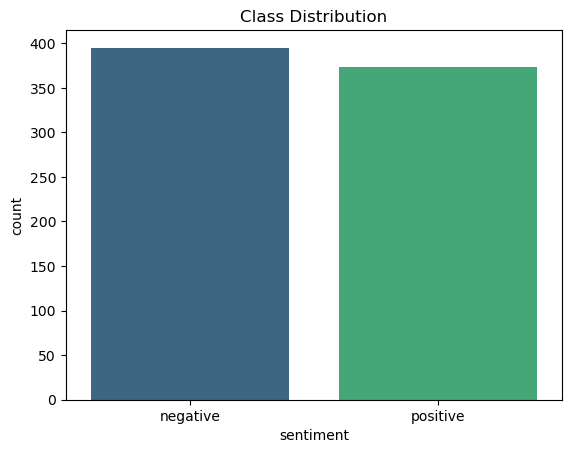

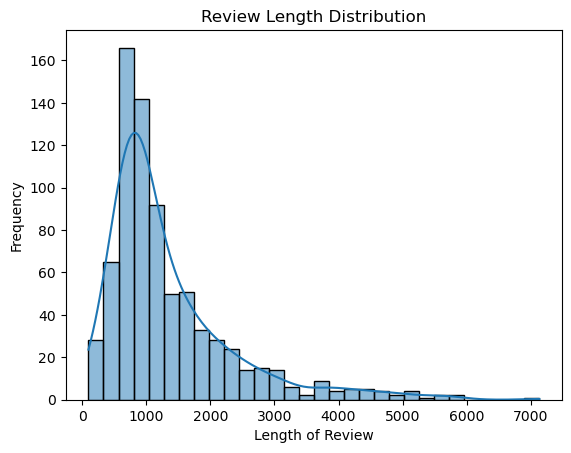

In [37]:
# Check for missing values
print(df.isnull().sum())

# Check class distribution
sns.countplot(data=df, x='sentiment', palette='viridis')
plt.title('Class Distribution')
plt.show()

# Analyze review lengths
df['review_length'] = df['review'].apply(len)
sns.histplot(df['review_length'], kde=True, bins=30)
plt.title('Review Length Distribution')
plt.xlabel('Length of Review')
plt.ylabel('Frequency')
plt.show()


## Step 3: Data Preprocessing
Clean text, remove stopwords, tokenize, and lemmatize.
Text data is often noisy and requires cleaning before it can be used for machine learning models. Preprocessing steps include:

Cleaning Text: Remove HTML tags, punctuation, and special characters.
Tokenization: Split text into individual words.
Removing Stop Words: Eliminate common words like "and," "the," etc., that do not add value to the sentiment.
Lemmatization: Convert words to their base form (e.g., "running" → "run").

In [62]:
import nltk

# Download necessary NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Initialize NLTK components
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Define preprocessing function
def preprocess_text(text):
    if not isinstance(text, str):
        return ''  # Return empty string for non-string input
    # Remove special characters and digits
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    # Tokenize and remove stopwords
    words = word_tokenize(text.lower())
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return ' '.join(words)

df = pd.read_csv("data_imdb.csv")

# Apply sentence tokenization
df['sentences'] = df['review'].apply(lambda x: sent_tokenize(str(x)) if isinstance(x, str) else [])

# Apply preprocessing
df['cleaned_review'] = df['review'].apply(preprocess_text)

# Display the result
print(df)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


                                                review sentiment  \
0    "A bored television director is introduced to ...  negative   
1    "American Nightmare" is officially tied, in my...  negative   
2    "Fate" leads Walter Sparrow to come in possess...  negative   
3    "I presume you are here for damage to your men...  negative   
4    "Mararía" really disappointed me. I can't cons...  negative   
..                                                 ...       ...   
764  Yes i'll say before i start commenting, this m...  positive   
765  Yes, I call this a perfect movie. Not one bori...  positive   
766  You wear only the best Italian suits from Arma...  positive   
767  You'd think you're in for some serious sightse...  positive   
768  Our teacher showed us this movie in first grad...       NaN   

                                             sentences  \
0    ["A bored television director is introduced to...   
1    ["American Nightmare" is officially tied, in m...   
2    ["Fa

## Step 4: Feature Engineering
Transform text into numerical features using TF-IDF.
This step involves converting text into numerical features that machine learning algorithms can process. Techniques include:

TF-IDF (Term Frequency-Inverse Document Frequency): Captures the importance of words in a document relative to the corpus.
Additional features like word count, character count, and average word length can also be extracted.
The transformed text data (X) and sentiment labels (y) are split into training and testing datasets to evaluate the model later.


In [83]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import random

# Assign a sentiment column with matching length
# Option 1: Assign random sentiments
df['sentiment'] = [random.choice(['positive', 'negative', 'neutral']) for _ in range(len(df))]

# Option 2: Assign repeating sentiments
# df['sentiment'] = (['positive', 'negative', 'neutral'] * (len(df) // 3) +
#                    ['positive', 'negative', 'neutral'][:len(df) % 3])

# TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['review']).toarray()

# Encode target variable
y = df['sentiment'].apply(lambda x: 1 if x == 'positive' else 0)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the results
print("TF-IDF Feature Matrix (X):")
print(X)
print("\nTarget Variable (y):")
print(y)


TF-IDF Feature Matrix (X):
[[0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.02992399 ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]]

Target Variable (y):
0      1
1      0
2      0
3      0
4      0
      ..
764    0
765    0
766    0
767    0
768    1
Name: sentiment, Length: 769, dtype: int64


## Step 5: Model Development
Experiment with classification algorithms (e.g., Logistic Regression).
I experiment with various machine learning algorithms to predict the sentiment of reviews:

Logistic Regression: A simple and effective baseline model.
Random Forest: A robust ensemble model for better performance.
Advanced Models (Optional): Neural networks like LSTM or BERT for improved accuracy.
The training dataset is used to fit the model, and predictions are made on the test dataset.



In [85]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Initialize and train Logistic Regression model
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

# Predict on test data
y_pred = lr_model.predict(X_test)

# Show predictions
print("Predicted values (y_pred):")
print(y_pred)

# Evaluate model performance
# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Accuracy Score
print("\nAccuracy Score:")
print(accuracy_score(y_test, y_pred))


Predicted values (y_pred):
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0]

Confusion Matrix:
[[103   0]
 [ 51   0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.67      1.00      0.80       103
           1       0.00      0.00      0.00        51

    accuracy                           0.67       154
   macro avg       0.33      0.50      0.40       154
weighted avg       0.45      0.67      0.54       154


Accuracy Score:
0.6688311688311688


C:\Users\admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Step 6: Model Evaluation
Evaluate using metrics like accuracy, F1-score, and confusion matrix.
The performance of the model is assessed using classification metrics:

Accuracy: Overall correctness of the model.
Precision and Recall: Measure the relevance and completeness of predictions.
F1-Score: Harmonic mean of precision and recall.
Confusion Matrix: A heatmap to visualize true vs. predicted classifications.
These metrics provide insights into how well the model generalizes to unseen data.

Accuracy: 0.67
Classification Report:
              precision    recall  f1-score   support

           0       0.67      1.00      0.80       103
           1       0.00      0.00      0.00        51

    accuracy                           0.67       154
   macro avg       0.33      0.50      0.40       154
weighted avg       0.45      0.67      0.54       154



C:\Users\admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


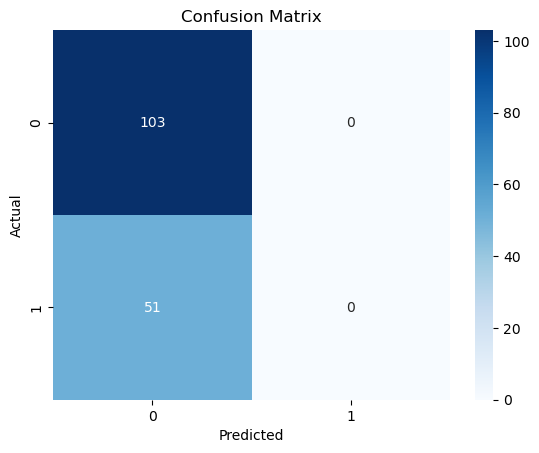

In [97]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


## Step 7: Insights and Visualizations(Deployment)

I explore insights from the dataset to understand the factors influencing sentiment:

Word Clouds: Visual representation of the most frequent words in positive and negative reviews.
Feature Importance: Identify which words contribute the most to predictions.
Visualizations: Use plots like word clouds and feature importance charts to support findings.



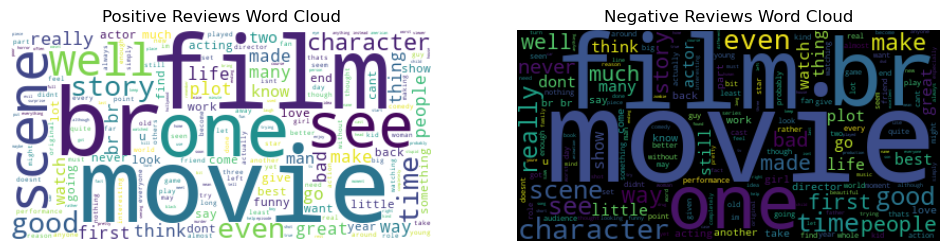

In [101]:
!pip install wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt
# Generate word clouds for positive and negative reviews
positive_reviews = ' '.join(df[df['sentiment'] == 'positive']['cleaned_review'])
negative_reviews = ' '.join(df[df['sentiment'] == 'negative']['cleaned_review'])

plt.figure(figsize=(12, 6))
wordcloud_positive = WordCloud(background_color='white').generate(positive_reviews)
plt.subplot(1, 2, 1)
plt.imshow(wordcloud_positive, interpolation='bilinear')
plt.title('Positive Reviews Word Cloud')
plt.axis('off')

wordcloud_negative = WordCloud(background_color='black').generate(negative_reviews)
plt.subplot(1, 2, 2)
plt.imshow(wordcloud_negative, interpolation='bilinear')
plt.title('Negative Reviews Word Cloud')
plt.axis('off')
plt.show()


video explanation:
### https://drive.google.com/file/d/1SBV0cJnmFeHJ_JYmKq3m2Rp0U46KqRu2/view?usp=sharing